# LOSOCV Stacked Ensemble - Full 60 Connectivity v4

Notebook này là bản tách riêng từ `model_training_losocv_full.ipynb`, dùng bộ feature mới `Full_MultiDomain_Features_Role3_v4`.

Mục tiêu:

- Dùng đủ 60 connectivity features theo paper.
- Chạy stacked ensemble LOSOCV giống flow paper.
- Tách 3 bài toán nhị phân thành 3 cell riêng để dễ chạy/dừng/tiếp tục.
- Ghi log tiến trình ra `notebook_outputs/full_paper_60_v4_split_losocv_run.log`.

Lưu ý: cần chạy xong `recompute_full_60_connectivity_features.ipynb` trước để tạo folder `Full_MultiDomain_Features_Role3_v4`.

## 1. Import thư viện

Cell này nạp thư viện xử lý dữ liệu, mô hình FgMDM, meta-classifier Logistic Regression Elastic Net và metric đánh giá.

In [1]:
from pathlib import Path
import json
import math
import os
import time
import warnings
from datetime import datetime
from typing import Callable

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyriemann.classification import FgMDM, class_distinctiveness
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore', category=FutureWarning)


## 2. Cấu hình chạy

Notebook này mặc định đọc feature mới từ `Full_MultiDomain_Features_Role3_v4`. Nếu folder này chưa tồn tại, hãy chạy notebook recompute feature trước.

In [2]:
ROOT = Path('/home/dohaidang/DataMining_Project')
PRECOMPUTED_DIR = ROOT / 'Full_MultiDomain_Features_Role3_v5'
OUTPUT_DIR = ROOT / 'notebook_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_TAG = 'full_paper_60_v4_split'
LOG_PATH = OUTPUT_DIR / f'{OUTPUT_TAG}_losocv_run.log'

PAPER_BANDS = ('delta', 'theta', 'alpha', 'beta', 'gamma')
PAPER_METRICS = ('cov', 'corr', 'xcov', 'xcorr', 'csd', 'coh', 'mi', 'ecc', 'aecov', 'aecorr', 'plv', 'wplv')

RANDOM_STATE = 42
INNER_FOLDS = 5
FGMDM_METRIC = 'euclid'
FGMDM_FALLBACK_METRICS = ('riemann',)
FILTER_RATIO = 0.5
ELASTICNET_ALPHA = 0.01
ELASTICNET_L1_RATIO = 0.15
USE_CACHED_RESULTS = True
OUTER_LIMIT = None

PROBLEMS = {
    'ad_hc': ('A', 'C', 'AD', 'HC'),
    'ftd_hc': ('F', 'C', 'FTD', 'HC'),
    'ftd_ad': ('F', 'A', 'FTD', 'AD'),
}

if not PRECOMPUTED_DIR.exists():
    raise FileNotFoundError(
        f'Chua co folder feature moi: {PRECOMPUTED_DIR}. '
        'Hay chay recompute_full_60_connectivity_features.ipynb truoc.'
    )

print('Feature folder:', PRECOMPUTED_DIR)
print('Output tag:', OUTPUT_TAG)
print('Log path:', LOG_PATH)
print('Total feature sets:', len(PAPER_BANDS) * len(PAPER_METRICS))


Feature folder: /home/dohaidang/DataMining_Project/Full_MultiDomain_Features_Role3_v5
Output tag: full_paper_60_v4_split
Log path: /home/dohaidang/DataMining_Project/notebook_outputs/full_paper_60_v4_split_losocv_run.log
Total feature sets: 60


## 3. Hàm log

`log_message` vừa in ra notebook, vừa append vào file log để nếu chạy lâu vẫn có dấu vết tiến trình.

In [3]:
def log_message(message: str) -> None:
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{timestamp}] {message}'
    print(line)
    with LOG_PATH.open('a', encoding='utf-8') as file:
        file.write(line + '\n')


log_message('Notebook initialized')


[2026-05-25 14:18:41] Notebook initialized


## 4. Nạp 60 feature mới

Loader dùng `mmap_mode='r'` để giảm RAM lúc nạp ban đầu. Feature v4 đã được project SPD trong bước recompute, nên notebook này không tính lại connectivity.

In [4]:
def normalize_subject_ids(subject_ids: np.ndarray) -> np.ndarray:
    normalized = []
    for subject_id in subject_ids.astype(str):
        if subject_id.startswith('sub-'):
            normalized.append(subject_id)
        else:
            normalized.append(f'sub-{subject_id.zfill(3)}')
    return np.asarray(normalized)


def expected_feature_names() -> list[str]:
    return [f'{band}_{metric}' for band in PAPER_BANDS for metric in PAPER_METRICS]


def validate_feature_folder(precomputed_dir: Path) -> None:
    required = ['labels.npy', 'subject_ids.npy'] + [f'{name}.npy' for name in expected_feature_names()]
    missing = [name for name in required if not (precomputed_dir / name).exists()]
    if missing:
        raise FileNotFoundError('Thieu file feature v4: ' + ', '.join(missing[:20]))


def load_precomputed_feature_catalog(precomputed_dir: Path):
    validate_feature_folder(precomputed_dir)
    labels = np.load(precomputed_dir / 'labels.npy', allow_pickle=True).astype(str)
    subject_ids = normalize_subject_ids(np.load(precomputed_dir / 'subject_ids.npy', allow_pickle=True))

    catalog = {}
    rows = []
    for feature_name in expected_feature_names():
        band, metric = feature_name.split('_', maxsplit=1)
        path = precomputed_dir / f'{feature_name}.npy'
        matrices = np.load(path, mmap_mode='r')
        catalog[f'{band}__{metric}'] = {
            'band': band,
            'metric': metric,
            'matrices': matrices,
            'labels': labels,
            'subject_ids': subject_ids,
            'path': str(path),
        }
        rows.append({
            'feature': f'{band}__{metric}',
            'band': band,
            'metric': metric,
            'shape': tuple(matrices.shape),
            'dtype': str(matrices.dtype),
        })
    return catalog, pd.DataFrame(rows)


feature_catalog, feature_load_log = load_precomputed_feature_catalog(PRECOMPUTED_DIR)
log_message(f'Loaded feature catalog: {len(feature_catalog)} feature sets')
feature_load_log.head()


[2026-05-25 14:18:41] Loaded feature catalog: 60 feature sets


,feature,band,metric,shape,dtype
0,delta__cov,delta,cov,"(13422, 19, 19)",float64
1,delta__corr,delta,corr,"(13422, 19, 19)",float64
2,delta__xcov,delta,xcov,"(13422, 19, 19)",float64
3,delta__xcorr,delta,xcorr,"(13422, 19, 19)",float64
4,delta__csd,delta,csd,"(13422, 19, 19)",float64


## 5. Kiểm tra label và subject

Cell này kiểm tra số epoch, số subject và phân bố nhãn trên toàn bộ dữ liệu.

In [5]:
reference_feature = next(iter(feature_catalog.values()))
epoch_df = pd.DataFrame({
    'subject_id': reference_feature['subject_ids'],
    'label': reference_feature['labels'],
})

summary = pd.DataFrame({
    'n_epochs': epoch_df.groupby('label').size(),
    'n_subjects': epoch_df.groupby('label')['subject_id'].nunique(),
})

log_message(f'Total epochs: {len(epoch_df)} | total subjects: {epoch_df.subject_id.nunique()}')
summary


[2026-05-25 14:18:41] Total epochs: 13422 | total subjects: 88


,n_epochs,n_subjects
label,,
A,5666,36
C,4603,29
F,3153,23


## 6. Hàm hỗ trợ LOSOCV

Các hàm này tạo subset nhị phân, tính sample weight theo subject, evaluate metric, và fit FgMDM với fallback metric nếu cần.

In [6]:
def nearest_spd_matrix(matrix: np.ndarray, jitter: float = 1e-6) -> np.ndarray:
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float64)
    symmetric = 0.5 * (matrix + matrix.T)
    eigvals, eigvecs = np.linalg.eigh(symmetric)
    eigvals = np.maximum(eigvals, jitter)
    stabilized = (eigvecs * eigvals) @ eigvecs.T
    stabilized = 0.5 * (stabilized + stabilized.T)
    stabilized += np.eye(stabilized.shape[0]) * jitter
    return stabilized


def stabilize_spd_stack(matrices: np.ndarray, jitter: float = 1e-6) -> np.ndarray:
    return np.stack([nearest_spd_matrix(matrix, jitter=jitter) for matrix in matrices]).astype(np.float64)


def binary_subset(feature_item, positive_code: str, negative_code: str):
    mask = np.isin(feature_item['labels'], [positive_code, negative_code])
    matrices = np.asarray(feature_item['matrices'][mask], dtype=np.float64)
    labels = (feature_item['labels'][mask] == positive_code).astype(int)
    subjects = feature_item['subject_ids'][mask]
    return matrices, labels, subjects


def build_subject_frame(labels: np.ndarray, subject_ids: np.ndarray):
    frame = pd.DataFrame({'subject_id': subject_ids, 'label': labels})
    subject_frame = frame.drop_duplicates('subject_id').sort_values('subject_id').reset_index(drop=True)
    counts = frame.groupby('subject_id').size().rename('epoch_count')
    subject_frame = subject_frame.merge(counts, on='subject_id', how='left')
    subject_frame['sample_weight'] = 1.0 / subject_frame['epoch_count']
    return subject_frame


def build_subject_table_for_problem(problem_name: str) -> pd.DataFrame:
    positive_code, negative_code, _, _ = PROBLEMS[problem_name]
    reference_feature = next(iter(feature_catalog.values()))
    _, y_binary, subject_ids_binary = binary_subset(reference_feature, positive_code, negative_code)
    subject_table = build_subject_frame(y_binary, subject_ids_binary)
    if OUTER_LIMIT is not None:
        subject_table = subject_table.iloc[:OUTER_LIMIT].copy().reset_index(drop=True)
    return subject_table


def epoch_weights(subject_ids: np.ndarray) -> np.ndarray:
    counts = pd.Series(subject_ids).value_counts()
    return np.asarray([1.0 / counts[sid] for sid in subject_ids], dtype=np.float64)


def safe_inner_folds(labels: np.ndarray, requested_folds: int) -> int:
    class_counts = np.bincount(labels.astype(int))
    min_count = int(class_counts.min())
    if min_count < 2:
        raise ValueError('At least two subjects per class are required for inner cross-validation.')
    return int(min(requested_folds, min_count))


def aggregate_probs_by_subject(probabilities: np.ndarray, subject_ids: np.ndarray) -> pd.Series:
    frame = pd.DataFrame({'subject_id': subject_ids, 'probability': probabilities})
    return frame.groupby('subject_id')['probability'].mean()


def evaluate_subject_predictions(y_true: np.ndarray, y_prob: np.ndarray):
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics = {
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'sensitivity': float(tp / (tp + fn) if (tp + fn) else 0.0),
        'specificity': float(tn / (tn + fp) if (tn + fp) else 0.0),
    }
    return metrics, y_pred


def build_meta_model(alpha: float, l1_ratio: float, random_state: int) -> LogisticRegression:
    return LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=l1_ratio,
        C=1.0 / alpha,
        max_iter=5000,
        random_state=random_state,
    )


def fit_fgmdm_with_fallback(X_train: np.ndarray, y_train: np.ndarray, sample_weight: np.ndarray):
    last_error = None
    for metric in (FGMDM_METRIC, *FGMDM_FALLBACK_METRICS):
        try:
            model = FgMDM(metric=metric)
            model.fit(X_train, y_train, sample_weight=sample_weight)
            return model, metric
        except ValueError as exc:
            last_error = exc
            X_train = stabilize_spd_stack(X_train)
    raise last_error


def safe_class_distinctiveness(X: np.ndarray, y: np.ndarray):
    last_error = None
    for metric in (FGMDM_METRIC, *FGMDM_FALLBACK_METRICS):
        try:
            return float(class_distinctiveness(X, y, metric=metric)), metric
        except ValueError as exc:
            last_error = exc
            X = stabilize_spd_stack(X)
    raise last_error


def predict_positive_proba(model, X: np.ndarray, positive_label: int = 1) -> np.ndarray:
    class_index = int(np.where(model.classes_ == positive_label)[0][0])
    return model.predict_proba(X)[:, class_index]


## 7. Train base FgMDM cho từng feature

Trong mỗi outer fold, mỗi feature được fit bằng FgMDM. Output của FgMDM là xác suất lớp dương, sau đó average từ epoch lên subject.

In [7]:
def fit_base_oof_predictions(
    feature_item,
    positive_code: str,
    negative_code: str,
    train_subject_ids: set[str],
    test_subject_id: str,
):
    X, y, subjects = binary_subset(feature_item, positive_code, negative_code)
    train_mask = np.isin(subjects, list(train_subject_ids))
    test_mask = subjects == test_subject_id

    X_train, y_train, s_train = X[train_mask], y[train_mask], subjects[train_mask]
    X_test, s_test = X[test_mask], subjects[test_mask]

    train_subject_frame = build_subject_frame(y_train, s_train)
    inner_splits = safe_inner_folds(train_subject_frame['label'].to_numpy(), INNER_FOLDS)
    inner_cv = StratifiedGroupKFold(n_splits=inner_splits, shuffle=True, random_state=RANDOM_STATE)
    sample_weight = epoch_weights(s_train)

    oof_epoch_prob = np.empty(y_train.shape[0], dtype=np.float64)
    for inner_train_idx, inner_valid_idx in inner_cv.split(X_train, y_train, s_train):
        model, _ = fit_fgmdm_with_fallback(
            X_train[inner_train_idx],
            y_train[inner_train_idx],
            sample_weight[inner_train_idx],
        )
        oof_epoch_prob[inner_valid_idx] = predict_positive_proba(model, X_train[inner_valid_idx])

    oof_subject_prob = aggregate_probs_by_subject(oof_epoch_prob, s_train)
    oof_subject_prob = oof_subject_prob.reindex(train_subject_frame['subject_id']).to_numpy()

    final_model, final_metric = fit_fgmdm_with_fallback(X_train, y_train, sample_weight)
    test_epoch_prob = predict_positive_proba(final_model, X_test)
    test_subject_prob = aggregate_probs_by_subject(test_epoch_prob, s_test)

    return oof_subject_prob, float(test_subject_prob.loc[test_subject_id]), final_metric


## 8. Wrapper feature selection và meta-classifier

Wrapper selection chọn dần các base predictions tốt nhất theo internal CV ROC-AUC. Meta-classifier là Logistic Regression Elastic Net.

In [8]:
def meta_score(X: np.ndarray, y: np.ndarray, sample_weight: np.ndarray, selected_columns: list[int]) -> float:
    n_splits = safe_inner_folds(y, INNER_FOLDS)
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, valid_idx in splitter.split(X[:, selected_columns], y):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X[train_idx][:, selected_columns])
        X_valid_scaled = scaler.transform(X[valid_idx][:, selected_columns])
        model = build_meta_model(ELASTICNET_ALPHA, ELASTICNET_L1_RATIO, RANDOM_STATE)
        model.fit(X_train_scaled, y[train_idx], sample_weight=sample_weight[train_idx])
        valid_prob = predict_positive_proba(model, X_valid_scaled)
        scores.append(roc_auc_score(y[valid_idx], valid_prob))
    return float(np.mean(scores))


def greedy_wrapper_selection(X: np.ndarray, y: np.ndarray, sample_weight: np.ndarray) -> list[int]:
    selected = []
    remaining = list(range(X.shape[1]))
    best_score = -math.inf
    while remaining:
        trial_scores = []
        for candidate in remaining:
            score = meta_score(X, y, sample_weight, selected + [candidate])
            trial_scores.append((score, candidate))
        trial_scores.sort(reverse=True)
        candidate_score, candidate_idx = trial_scores[0]
        if not selected or candidate_score > best_score:
            selected.append(candidate_idx)
            remaining.remove(candidate_idx)
            best_score = candidate_score
        else:
            break
    return selected


## 9. Hàm chạy LOSOCV stacked ensemble có log

Hàm này là lõi của notebook. Mỗi fold sẽ log subject test, số feature được giữ sau filter, feature được wrapper chọn, xác suất dự đoán và thời gian fold.

In [9]:
def run_losocv_stacked_model(
    problem_name: str,
    subject_table: pd.DataFrame,
    log_fn: Callable[[str], None] | None = None,
):
    positive_code, negative_code, positive_name, negative_name = PROBLEMS[problem_name]
    outer_predictions = []
    fold_artifacts = []
    total_folds = len(subject_table)
    start_problem = time.time()

    if log_fn:
        class_counts = subject_table['label'].value_counts().to_dict()
        log_fn(f'START {problem_name} ({positive_name} vs {negative_name}) | folds={total_folds} | class_counts={class_counts}')

    for local_fold_idx, (_, test_row) in enumerate(subject_table.iterrows(), start=1):
        fold_start = time.time()
        test_subject_id = str(test_row['subject_id'])
        train_subject_table = subject_table[subject_table['subject_id'] != test_subject_id].reset_index(drop=True)
        train_subject_ids = set(train_subject_table['subject_id'])

        distinctiveness_scores = {}
        for name, feature_item in feature_catalog.items():
            X, y, subjects = binary_subset(feature_item, positive_code, negative_code)
            train_mask = np.isin(subjects, list(train_subject_ids))
            score, _ = safe_class_distinctiveness(X[train_mask], y[train_mask])
            distinctiveness_scores[name] = score

        ranked = sorted(distinctiveness_scores.items(), key=lambda item: item[1], reverse=True)
        retain_count = max(1, int(math.ceil(len(ranked) * FILTER_RATIO)))
        retained_features = [name for name, _ in ranked[:retain_count]]

        meta_columns_train = []
        meta_columns_test = []
        feature_fit_metrics = {}
        for feature_name in retained_features:
            oof_subject_prob, test_subject_prob, fit_metric = fit_base_oof_predictions(
                feature_catalog[feature_name],
                positive_code,
                negative_code,
                train_subject_ids,
                test_subject_id,
            )
            feature_fit_metrics[feature_name] = fit_metric
            meta_columns_train.append(oof_subject_prob)
            meta_columns_test.append(test_subject_prob)

        X_meta_train = np.column_stack(meta_columns_train)
        y_meta_train = train_subject_table['label'].to_numpy()
        sample_weight = train_subject_table['sample_weight'].to_numpy(dtype=np.float64)

        selected_indices = greedy_wrapper_selection(X_meta_train, y_meta_train, sample_weight)
        if not selected_indices:
            selected_indices = [0]

        scaler = StandardScaler()
        X_meta_train_selected = scaler.fit_transform(X_meta_train[:, selected_indices])
        meta_model = build_meta_model(ELASTICNET_ALPHA, ELASTICNET_L1_RATIO, RANDOM_STATE)
        meta_model.fit(X_meta_train_selected, y_meta_train, sample_weight=sample_weight)

        X_meta_test = np.asarray(meta_columns_test, dtype=np.float64)[selected_indices].reshape(1, -1)
        X_meta_test_scaled = scaler.transform(X_meta_test)
        test_prob = float(predict_positive_proba(meta_model, X_meta_test_scaled)[0])
        selected_features = [retained_features[idx] for idx in selected_indices]

        outer_predictions.append({
            'subject_id': test_subject_id,
            'y_true': int(test_row['label']),
            'y_prob': test_prob,
        })
        fold_artifacts.append({
            'fold_index': int(local_fold_idx),
            'test_subject_id': test_subject_id,
            'retained_features': retained_features,
            'selected_features': selected_features,
            'feature_fit_metrics': feature_fit_metrics,
            'top_distinctiveness': ranked[:10],
            'seconds': time.time() - fold_start,
        })

        if log_fn:
            elapsed = time.time() - fold_start
            log_fn(
                f'{problem_name} fold {local_fold_idx:03d}/{total_folds} | '
                f'test={test_subject_id} | y={int(test_row["label"])} | prob={test_prob:.6f} | '
                f'retained={len(retained_features)} | selected={selected_features} | {elapsed:.1f}s'
            )

    predictions_df = pd.DataFrame(outer_predictions)
    metrics, y_pred = evaluate_subject_predictions(
        predictions_df['y_true'].to_numpy(),
        predictions_df['y_prob'].to_numpy(),
    )

    if log_fn:
        log_fn(f'END {problem_name} | metrics={metrics} | total_seconds={time.time() - start_problem:.1f}')

    return predictions_df, fold_artifacts, metrics, y_pred


## 10. Hàm lưu và load kết quả từng bài toán

Mỗi bài toán có 3 output riêng: metrics CSV, subject predictions CSV, fold artifacts JSON.

In [10]:
def result_paths(problem_name: str):
    return {
        'metrics': OUTPUT_DIR / f'{OUTPUT_TAG}_{problem_name}_losocv_metrics.csv',
        'predictions': OUTPUT_DIR / f'{OUTPUT_TAG}_{problem_name}_losocv_subject_predictions.csv',
        'folds': OUTPUT_DIR / f'{OUTPUT_TAG}_{problem_name}_losocv_fold_artifacts.json',
    }


def load_problem_result(problem_name: str):
    paths = result_paths(problem_name)
    metrics = pd.read_csv(paths['metrics'], index_col=0).iloc[0].to_dict()
    predictions = pd.read_csv(paths['predictions'])
    folds = json.loads(paths['folds'].read_text())
    return {
        'predictions': predictions,
        'folds': folds,
        'metrics': metrics,
    }


def save_problem_result(problem_name: str, predictions: pd.DataFrame, folds: list[dict], metrics: dict) -> None:
    paths = result_paths(problem_name)
    pd.DataFrame([metrics], index=['losocv_stacked_model']).to_csv(paths['metrics'])
    predictions.to_csv(paths['predictions'], index=False)
    paths['folds'].write_text(json.dumps(folds, indent=2), encoding='utf-8')
    log_message(f'Saved {problem_name}: {paths}')


def run_or_load_problem(problem_name: str):
    paths = result_paths(problem_name)
    if USE_CACHED_RESULTS and all(path.exists() for path in paths.values()):
        log_message(f'LOAD cached result: {problem_name}')
        return load_problem_result(problem_name)

    subject_table = build_subject_table_for_problem(problem_name)
    predictions, folds, metrics, _ = run_losocv_stacked_model(
        problem_name=problem_name,
        subject_table=subject_table,
        log_fn=log_message,
    )
    save_problem_result(problem_name, predictions, folds, metrics)
    return {
        'predictions': predictions,
        'folds': folds,
        'metrics': metrics,
    }


all_results = {}


## 11. Chạy bài toán 1: AD vs HC

Cell này chỉ chạy hoặc load kết quả `ad_hc`. Nếu đã có output và `USE_CACHED_RESULTS=True`, notebook sẽ đọc lại để tiết kiệm thời gian.

In [11]:
ad_hc_result = run_or_load_problem('ad_hc')
all_results['ad_hc'] = ad_hc_result
pd.DataFrame([ad_hc_result['metrics']], index=['ad_hc'])


[2026-05-25 14:18:41] START ad_hc (AD vs HC) | folds=65 | class_counts={1: 36, 0: 29}
[2026-05-25 14:20:07] ad_hc fold 001/65 | test=sub-001 | y=1 | prob=0.873226 | retained=30 | selected=['alpha__ecc', 'beta__corr', 'delta__coh'] | 85.3s
[2026-05-25 14:21:28] ad_hc fold 002/65 | test=sub-002 | y=1 | prob=0.743247 | retained=30 | selected=['alpha__ecc', 'beta__corr', 'theta__ecc'] | 81.7s
[2026-05-25 14:22:47] ad_hc fold 003/65 | test=sub-003 | y=1 | prob=0.318580 | retained=30 | selected=['alpha__ecc', 'beta__corr', 'delta__coh'] | 79.3s
[2026-05-25 14:24:02] ad_hc fold 004/65 | test=sub-004 | y=1 | prob=0.945675 | retained=30 | selected=['alpha__plv', 'alpha__ecc', 'beta__corr', 'theta__mi'] | 74.9s
[2026-05-25 14:25:16] ad_hc fold 005/65 | test=sub-005 | y=1 | prob=0.613183 | retained=30 | selected=['alpha__ecc', 'beta__coh'] | 74.1s
[2026-05-25 14:26:30] ad_hc fold 006/65 | test=sub-006 | y=1 | prob=0.644286 | retained=30 | selected=['alpha__ecc', 'theta__ecc', 'beta__corr'] | 73.5

,roc_auc,accuracy,f1,sensitivity,specificity
ad_hc,0.827586,0.707692,0.753247,0.805556,0.586207


## 12. Chạy bài toán 2: FTD vs HC

Cell này chỉ chạy hoặc load kết quả `ftd_hc`.

In [12]:
ftd_hc_result = run_or_load_problem('ftd_hc')
all_results['ftd_hc'] = ftd_hc_result
pd.DataFrame([ftd_hc_result['metrics']], index=['ftd_hc'])


[2026-05-25 15:35:39] START ftd_hc (FTD vs HC) | folds=52 | class_counts={0: 29, 1: 23}
[2026-05-25 15:36:43] ftd_hc fold 001/52 | test=sub-037 | y=0 | prob=0.019259 | retained=30 | selected=['alpha__ecc', 'gamma__corr'] | 64.4s
[2026-05-25 15:37:42] ftd_hc fold 002/52 | test=sub-038 | y=0 | prob=0.253088 | retained=30 | selected=['alpha__aecorr', 'gamma__mi', 'theta__corr'] | 59.2s
[2026-05-25 15:38:48] ftd_hc fold 003/52 | test=sub-039 | y=0 | prob=0.046106 | retained=30 | selected=['alpha__aecorr', 'gamma__mi', 'theta__ecc'] | 65.4s
[2026-05-25 15:40:10] ftd_hc fold 004/52 | test=sub-040 | y=0 | prob=0.098959 | retained=30 | selected=['alpha__aecorr', 'beta__mi', 'alpha__mi', 'theta__ecc'] | 82.4s
[2026-05-25 15:41:23] ftd_hc fold 005/52 | test=sub-041 | y=0 | prob=0.488931 | retained=30 | selected=['alpha__ecc'] | 73.1s
[2026-05-25 15:42:25] ftd_hc fold 006/52 | test=sub-042 | y=0 | prob=0.224975 | retained=30 | selected=['alpha__aecorr', 'beta__aecorr'] | 61.9s
[2026-05-25 15:43:4

,roc_auc,accuracy,f1,sensitivity,specificity
ftd_hc,0.761619,0.692308,0.666667,0.695652,0.689655


## 13. Chạy bài toán 3: FTD vs AD

Cell này chỉ chạy hoặc load kết quả `ftd_ad`. Đây thường là bài toán khó nhất và cần chú ý sensitivity/recall.

In [13]:
ftd_ad_result = run_or_load_problem('ftd_ad')
all_results['ftd_ad'] = ftd_ad_result
pd.DataFrame([ftd_ad_result['metrics']], index=['ftd_ad'])


[2026-05-25 16:29:20] START ftd_ad (FTD vs AD) | folds=59 | class_counts={0: 36, 1: 23}
[2026-05-25 16:30:22] ftd_ad fold 001/59 | test=sub-001 | y=0 | prob=0.205110 | retained=30 | selected=['delta__ecc', 'theta__mi', 'alpha__wplv'] | 62.6s
[2026-05-25 16:31:31] ftd_ad fold 002/59 | test=sub-002 | y=0 | prob=0.363237 | retained=30 | selected=['alpha__plv', 'alpha__ecc', 'delta__ecc', 'alpha__coh', 'gamma__corr', 'theta__mi'] | 69.1s
[2026-05-25 16:32:35] ftd_ad fold 003/59 | test=sub-003 | y=0 | prob=0.584206 | retained=30 | selected=['alpha__corr', 'alpha__mi', 'alpha__wplv', 'alpha__plv'] | 63.6s
[2026-05-25 16:33:33] ftd_ad fold 004/59 | test=sub-004 | y=0 | prob=0.407501 | retained=30 | selected=['alpha__corr'] | 57.9s
[2026-05-25 16:34:35] ftd_ad fold 005/59 | test=sub-005 | y=0 | prob=0.503110 | retained=30 | selected=['delta__corr', 'alpha__mi', 'alpha__plv', 'delta__coh'] | 61.7s
[2026-05-25 16:35:40] ftd_ad fold 006/59 | test=sub-006 | y=0 | prob=0.675518 | retained=30 | sele

,roc_auc,accuracy,f1,sensitivity,specificity
ftd_ad,0.629227,0.610169,0.378378,0.304348,0.805556


## 14. Load lại kết quả nếu kernel bị restart

Nếu đã chạy xong 3 bài toán nhưng kernel bị restart, chạy cell này để nạp lại các file đã lưu.

In [14]:
for problem_name in PROBLEMS:
    paths = result_paths(problem_name)
    if problem_name not in all_results and all(path.exists() for path in paths.values()):
        all_results[problem_name] = load_problem_result(problem_name)
        log_message(f'Reloaded saved result into all_results: {problem_name}')

print('Problems available:', list(all_results))


Problems available: ['ad_hc', 'ftd_hc', 'ftd_ad']


## 15. Bảng tổng hợp kết quả 3 bài toán

Bảng này dùng để đưa vào phần Results: `ROC-AUC`, `accuracy`, `F1`, `sensitivity`, `specificity` và dòng trung bình.

In [15]:
required_problems = ['ad_hc', 'ftd_hc', 'ftd_ad']
missing_results = [name for name in required_problems if name not in all_results]
if missing_results:
    raise RuntimeError('Chua co ket qua cho: ' + ', '.join(missing_results))

metrics_summary = pd.DataFrame({
    problem_name: all_results[problem_name]['metrics']
    for problem_name in required_problems
}).T

metrics_summary.index.name = 'problem'
metrics_summary.loc['mean'] = metrics_summary.mean(numeric_only=True)

summary_path = OUTPUT_DIR / f'{OUTPUT_TAG}_all_binary_losocv_metrics_summary.csv'
metrics_summary.to_csv(summary_path)
log_message(f'Saved metrics summary: {summary_path}')
metrics_summary


[2026-05-25 17:33:51] Saved metrics summary: /home/dohaidang/DataMining_Project/notebook_outputs/full_paper_60_v4_split_all_binary_losocv_metrics_summary.csv


,roc_auc,accuracy,f1,sensitivity,specificity
problem,,,,,
ad_hc,0.827586,0.707692,0.753247,0.805556,0.586207
ftd_hc,0.761619,0.692308,0.666667,0.695652,0.689655
ftd_ad,0.629227,0.610169,0.378378,0.304348,0.805556
mean,0.739477,0.670056,0.599431,0.601852,0.693806


## 16. Biểu đồ so sánh metric

Biểu đồ giúp nhìn nhanh bài toán nào tốt/yếu hơn. Với dữ liệu này, `FTD vs AD` thường là bài toán khó nhất.

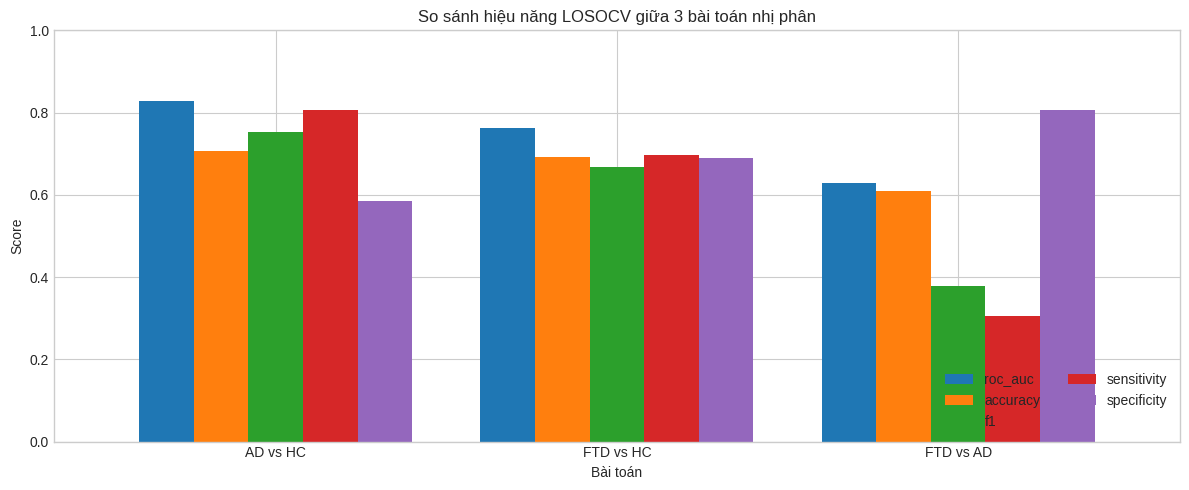

In [16]:
plot_metrics = ['roc_auc', 'accuracy', 'f1', 'sensitivity', 'specificity']
problem_labels = {
    'ad_hc': 'AD vs HC',
    'ftd_hc': 'FTD vs HC',
    'ftd_ad': 'FTD vs AD',
}

ax = metrics_summary.drop(index='mean')[plot_metrics].rename(index=problem_labels).plot(
    kind='bar',
    figsize=(12, 5),
    ylim=(0, 1),
    width=0.8,
)
ax.set_title('So sánh hiệu năng LOSOCV giữa 3 bài toán nhị phân')
ax.set_xlabel('Bài toán')
ax.set_ylabel('Score')
ax.legend(loc='lower right', ncol=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 17. ROC curves cho 3 bài toán

Cell này mô phỏng tinh thần Fig. 5 trong paper: so sánh ROC curves của stacked ensemble.

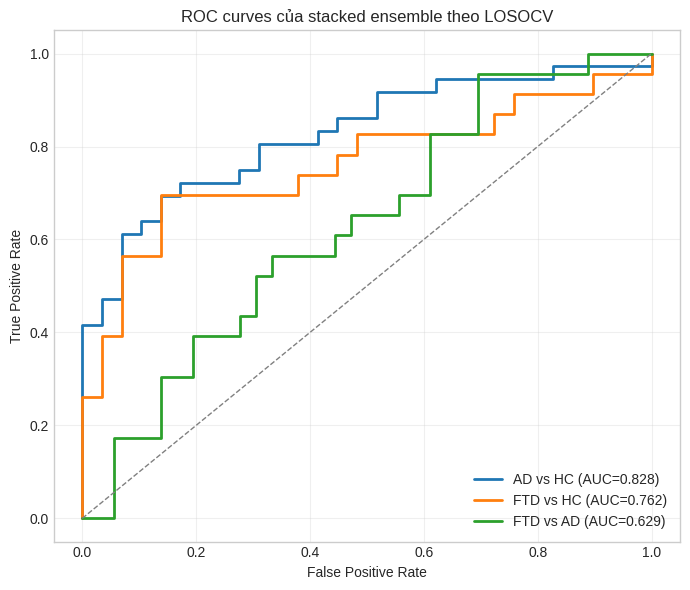

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))

for problem_name in required_problems:
    result = all_results[problem_name]
    predictions = result['predictions']
    fpr, tpr, _ = roc_curve(predictions['y_true'], predictions['y_prob'])
    auc_value = roc_auc_score(predictions['y_true'], predictions['y_prob'])
    ax.plot(fpr, tpr, linewidth=2, label=f"{problem_labels[problem_name]} (AUC={auc_value:.3f})")

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_title('ROC curves của stacked ensemble theo LOSOCV')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 18. Confusion Matrix cho từng bài toán

Confusion matrix dùng ngưỡng mặc định `0.5` trên xác suất lớp dương.

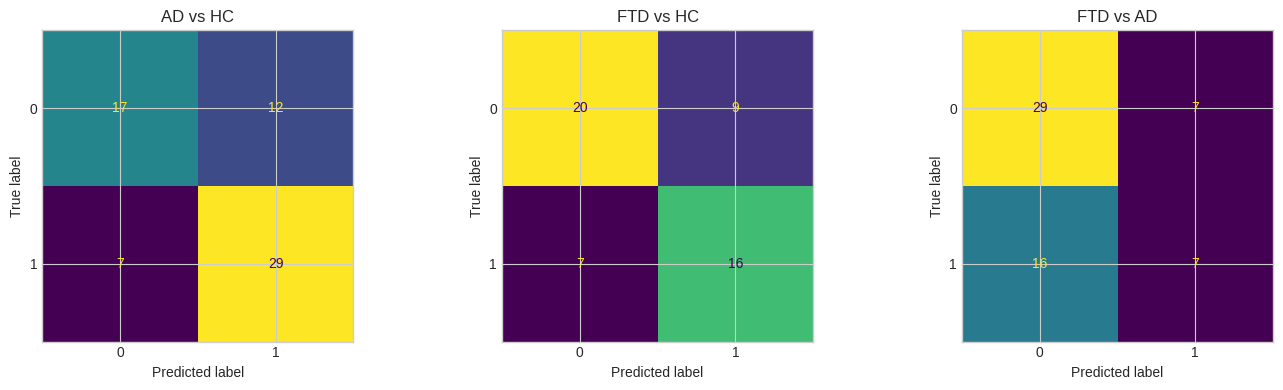

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, problem_name in zip(axes, required_problems):
    result = all_results[problem_name]
    predictions = result['predictions'].copy()
    predictions['y_pred'] = (predictions['y_prob'] >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        predictions['y_true'],
        predictions['y_pred'],
        ax=ax,
        colorbar=False,
    )
    ax.set_title(problem_labels[problem_name])

plt.tight_layout()
plt.show()


## 19. So sánh ROC-AUC với paper

Giá trị paper: AD/HC `0.8180`, FTD/HC `0.7136`, FTD/AD `0.6510`.

In [19]:
paper_auc = pd.Series({
    'ad_hc': 0.8180,
    'ftd_hc': 0.7136,
    'ftd_ad': 0.6510,
}, name='paper_auc')

comparison_auc = pd.DataFrame({
    'project_auc': metrics_summary.drop(index='mean')['roc_auc'],
    'paper_auc': paper_auc,
})
comparison_auc.index = comparison_auc.index.map(problem_labels)
comparison_auc['difference_project_minus_paper'] = comparison_auc['project_auc'] - comparison_auc['paper_auc']
comparison_auc


,project_auc,paper_auc,difference_project_minus_paper
AD vs HC,0.827586,0.8180,0.009586
FTD vs HC,0.761619,0.7136,0.048019
FTD vs AD,0.629227,0.6510,-0.021773


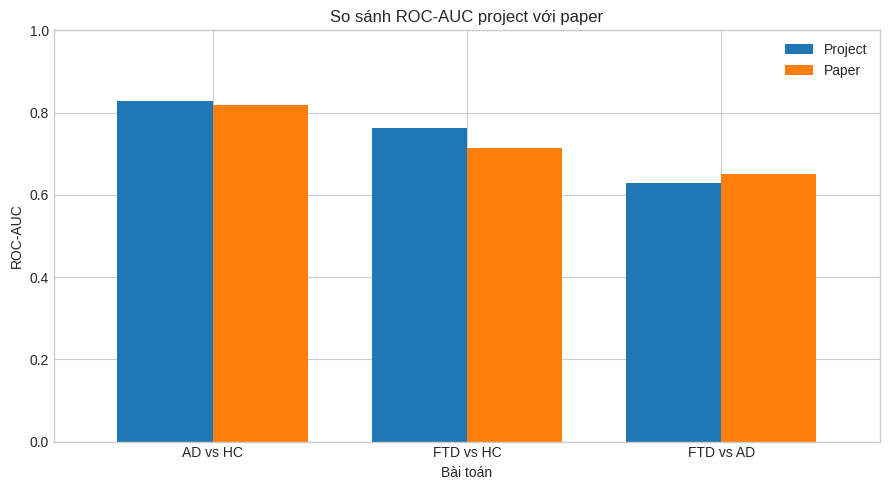

In [20]:
ax = comparison_auc[['project_auc', 'paper_auc']].plot(
    kind='bar',
    figsize=(9, 5),
    ylim=(0, 1),
    width=0.75,
)
ax.set_title('So sánh ROC-AUC project với paper')
ax.set_xlabel('Bài toán')
ax.set_ylabel('ROC-AUC')
ax.legend(['Project', 'Paper'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 20. Feature được wrapper selection chọn nhiều nhất

Cell này tổng hợp tần suất feature được chọn trong stacked model qua các fold.

In [21]:
feature_selection_rows = []
for problem_name in required_problems:
    result = all_results[problem_name]
    for fold in result['folds']:
        for feature_name in fold.get('selected_features', []):
            feature_selection_rows.append({
                'problem': problem_name,
                'feature': feature_name,
            })

feature_selection_df = pd.DataFrame(feature_selection_rows)
feature_selection_counts = (
    feature_selection_df
    .value_counts(['problem', 'feature'])
    .rename('selected_count')
    .reset_index()
)

feature_selection_pivot = feature_selection_counts.pivot(
    index='feature',
    columns='problem',
    values='selected_count',
).fillna(0).astype(int)

feature_selection_pivot = feature_selection_pivot.rename(columns=problem_labels)
feature_selection_pivot


problem,AD vs HC,FTD vs AD,FTD vs HC
feature,,,
alpha__aecorr,15,0,19
alpha__coh,2,18,1
alpha__corr,11,20,1
alpha__ecc,17,2,26
alpha__mi,3,20,4
alpha__plv,19,30,8
alpha__wplv,5,24,6
beta__aecorr,1,0,2
beta__coh,13,0,3


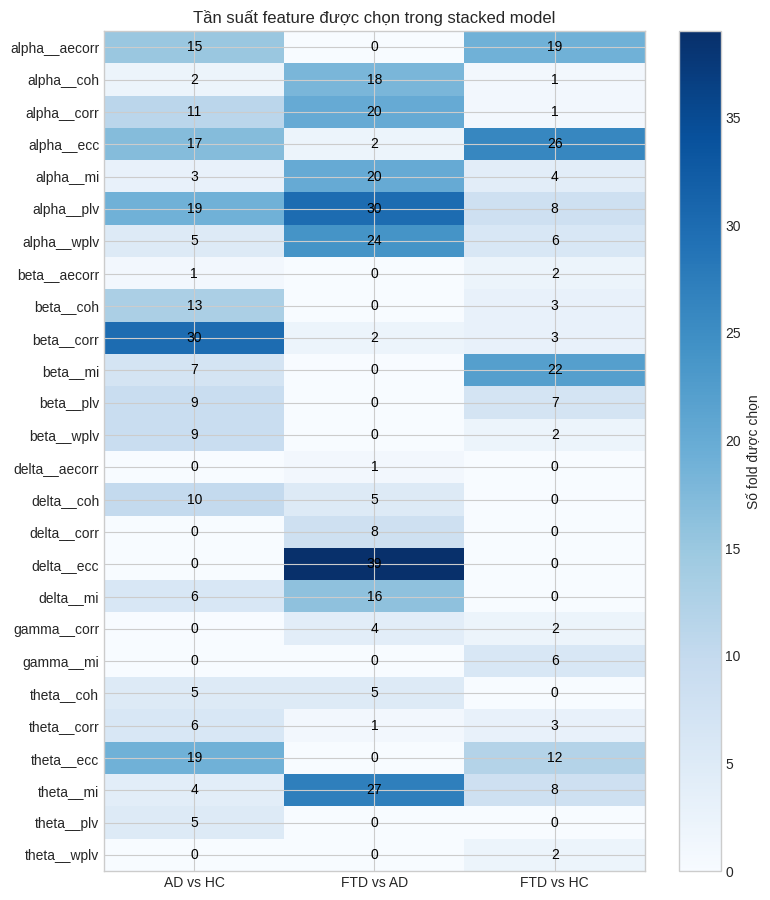

In [22]:
if feature_selection_pivot.empty:
    print('Khong co feature nao duoc ghi nhan trong fold artifacts.')
else:
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(feature_selection_pivot))))
    im = ax.imshow(feature_selection_pivot.to_numpy(), aspect='auto', cmap='Blues')

    ax.set_xticks(range(feature_selection_pivot.shape[1]))
    ax.set_xticklabels(feature_selection_pivot.columns, rotation=0)
    ax.set_yticks(range(feature_selection_pivot.shape[0]))
    ax.set_yticklabels(feature_selection_pivot.index)
    ax.set_title('Tần suất feature được chọn trong stacked model')

    for i in range(feature_selection_pivot.shape[0]):
        for j in range(feature_selection_pivot.shape[1]):
            value = feature_selection_pivot.iloc[i, j]
            ax.text(j, i, str(value), ha='center', va='center', color='black')

    fig.colorbar(im, ax=ax, label='Số fold được chọn')
    plt.tight_layout()
    plt.show()


## 21. Xem file log

Cell này đọc lại phần cuối của log để kiểm tra tiến trình/chẩn đoán khi chạy lâu.

In [23]:
if LOG_PATH.exists():
    lines = LOG_PATH.read_text(encoding='utf-8').splitlines()
    print('\n'.join(lines[-50:]))
else:
    print('Chua co file log:', LOG_PATH)


[2026-05-25 16:43:23] ftd_ad fold 013/59 | test=sub-013 | y=0 | prob=0.400101 | retained=30 | selected=['delta__mi', 'theta__mi', 'delta__ecc', 'alpha__wplv', 'alpha__coh', 'alpha__plv'] | 64.9s
[2026-05-25 16:44:27] ftd_ad fold 014/59 | test=sub-014 | y=0 | prob=0.228543 | retained=30 | selected=['delta__corr', 'alpha__mi', 'alpha__plv', 'alpha__corr'] | 64.0s
[2026-05-25 16:45:31] ftd_ad fold 015/59 | test=sub-015 | y=0 | prob=0.332494 | retained=30 | selected=['alpha__corr', 'alpha__mi', 'delta__ecc', 'delta__corr'] | 64.2s
[2026-05-25 16:46:36] ftd_ad fold 016/59 | test=sub-016 | y=0 | prob=0.162739 | retained=30 | selected=['alpha__corr', 'delta__ecc', 'alpha__mi', 'alpha__plv', 'theta__mi'] | 65.0s
[2026-05-25 16:47:45] ftd_ad fold 017/59 | test=sub-017 | y=0 | prob=0.175081 | retained=30 | selected=['delta__mi', 'theta__mi', 'delta__ecc', 'alpha__plv', 'alpha__mi', 'alpha__coh'] | 68.6s
[2026-05-25 16:48:52] ftd_ad fold 018/59 | test=sub-018 | y=0 | prob=0.079541 | retained=30 |

In [27]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    roc_auc_score,
)
import numpy as np
import pandas as pd

PAPER_METRIC_NAMES = [
    'roc_auc',
    'accuracy',
    'sensitivity',
    'specificity',
    'precision',
    'f1',
]

PROBLEM_LABELS = {
    'ad_hc': 'AD vs HC',
    'ftd_hc': 'FTD vs HC',
    'ftd_ad': 'FTD vs AD',
}

POSITIVE_CLASS_LABELS = {
    'ad_hc': 'AD',
    'ftd_hc': 'FTD',
    'ftd_ad': 'FTD',
}

NEGATIVE_CLASS_LABELS = {
    'ad_hc': 'HC',
    'ftd_hc': 'HC',
    'ftd_ad': 'AD',
}


def compute_paper_metrics_from_predictions(predictions_df: pd.DataFrame, threshold: float = 0.5) -> dict:
    y_true = predictions_df['y_true'].to_numpy()
    y_prob = predictions_df['y_prob'].to_numpy()
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        'roc_auc': roc_auc_score(y_true, y_prob),
        'accuracy': accuracy_score(y_true, y_pred),
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'threshold': threshold,
    }


paper_style_rows = []

for problem_name in ['ad_hc', 'ftd_hc', 'ftd_ad']:
    if 'all_results' in globals() and problem_name in all_results:
        predictions_df = all_results[problem_name]['predictions']
    else:
        pred_path = OUTPUT_DIR / f'{OUTPUT_TAG}_{problem_name}_losocv_subject_predictions.csv'
        predictions_df = pd.read_csv(pred_path)

    metrics = compute_paper_metrics_from_predictions(predictions_df, threshold=0.5)

    paper_style_rows.append({
        'problem': problem_name,
        'problem_label': PROBLEM_LABELS[problem_name],
        'positive_class': POSITIVE_CLASS_LABELS[problem_name],
        'negative_class': NEGATIVE_CLASS_LABELS[problem_name],
        **metrics,
    })

paper_style_metrics_df = pd.DataFrame(paper_style_rows)
paper_style_metrics_df = paper_style_metrics_df.set_index('problem')

paper_style_metrics_df[
    [
        'problem_label',
        'positive_class',
        'negative_class',
        'roc_auc',
        'accuracy',
        'sensitivity',
        'specificity',
        'precision',
        'f1',
        'tn',
        'fp',
        'fn',
        'tp',
    ]
]

,problem_label,positive_class,negative_class,roc_auc,accuracy,sensitivity,specificity,precision,f1,tn,fp,fn,tp
problem,,,,,,,,,,,,,
ad_hc,AD vs HC,AD,HC,0.827586,0.707692,0.805556,0.586207,0.707317,0.753247,17,12,7,29
ftd_hc,FTD vs HC,FTD,HC,0.761619,0.692308,0.695652,0.689655,0.640000,0.666667,20,9,7,16
ftd_ad,FTD vs AD,FTD,AD,0.629227,0.610169,0.304348,0.805556,0.500000,0.378378,29,7,16,7


In [28]:
numeric_cols = [
    'roc_auc',
    'accuracy',
    'sensitivity',
    'specificity',
    'precision',
    'f1',
]

paper_style_summary_df = paper_style_metrics_df.copy()

mean_row = {
    'problem_label': 'Mean',
    'positive_class': '-',
    'negative_class': '-',
}

for col in numeric_cols:
    mean_row[col] = paper_style_summary_df[col].mean()

for col in ['tn', 'fp', 'fn', 'tp']:
    mean_row[col] = np.nan

mean_row['threshold'] = 0.5

paper_style_summary_df.loc['mean'] = mean_row

paper_style_summary_df[
    [
        'problem_label',
        'roc_auc',
        'accuracy',
        'sensitivity',
        'specificity',
        'precision',
        'f1',
    ]
]

,problem_label,roc_auc,accuracy,sensitivity,specificity,precision,f1
problem,,,,,,,
ad_hc,AD vs HC,0.827586,0.707692,0.805556,0.586207,0.707317,0.753247
ftd_hc,FTD vs HC,0.761619,0.692308,0.695652,0.689655,0.640000,0.666667
ftd_ad,FTD vs AD,0.629227,0.610169,0.304348,0.805556,0.500000,0.378378
mean,Mean,0.739477,0.670056,0.601852,0.693806,0.615772,0.599431


In [29]:
paper_reported_metrics = pd.DataFrame(
    {
        'paper_roc_auc': {
            'ad_hc': 0.8180,
            'ftd_hc': 0.7136,
            'ftd_ad': 0.6510,
        },
        'paper_accuracy': {
            'ad_hc': 0.7385,
            'ftd_hc': 0.7115,
            'ftd_ad': 0.6949,
        },
        'paper_sensitivity': {
            'ad_hc': 0.6944,
            'ftd_hc': 0.6957,
            'ftd_ad': 0.7391,
        },
        'paper_specificity': {
            'ad_hc': 0.7931,
            'ftd_hc': 0.7241,
            'ftd_ad': 0.6538,
        },
        'paper_f1': {
            'ad_hc': 0.7463,
            'ftd_hc': 0.6809,
            'ftd_ad': 0.6538,
        },
    }
)

project_for_comparison = paper_style_metrics_df[
    ['roc_auc', 'accuracy', 'sensitivity', 'specificity', 'f1']
].rename(
    columns={
        'roc_auc': 'project_roc_auc',
        'accuracy': 'project_accuracy',
        'sensitivity': 'project_sensitivity',
        'specificity': 'project_specificity',
        'f1': 'project_f1',
    }
)

paper_comparison_df = project_for_comparison.join(paper_reported_metrics)

paper_comparison_df['auc_project_minus_paper'] = (
    paper_comparison_df['project_roc_auc'] - paper_comparison_df['paper_roc_auc']
)

paper_comparison_df.insert(
    0,
    'problem_label',
    paper_comparison_df.index.map(PROBLEM_LABELS),
)

paper_comparison_df

,problem_label,project_roc_auc,project_accuracy,project_sensitivity,project_specificity,project_f1,paper_roc_auc,paper_accuracy,paper_sensitivity,paper_specificity,paper_f1,auc_project_minus_paper
problem,,,,,,,,,,,,
ad_hc,AD vs HC,0.827586,0.707692,0.805556,0.586207,0.753247,0.8180,0.7385,0.6944,0.7931,0.7463,0.009586
ftd_hc,FTD vs HC,0.761619,0.692308,0.695652,0.689655,0.666667,0.7136,0.7115,0.6957,0.7241,0.6809,0.048019
ftd_ad,FTD vs AD,0.629227,0.610169,0.304348,0.805556,0.378378,0.6510,0.6949,0.7391,0.6538,0.6538,-0.021773


In [30]:
report_table_df = paper_style_summary_df[
    [
        'problem_label',
        'roc_auc',
        'accuracy',
        'sensitivity',
        'specificity',
        'precision',
        'f1',
    ]
].copy()

for col in ['roc_auc', 'accuracy', 'sensitivity', 'specificity', 'precision', 'f1']:
    report_table_df[col] = report_table_df[col].astype(float).round(4)

report_table_df

,problem_label,roc_auc,accuracy,sensitivity,specificity,precision,f1
problem,,,,,,,
ad_hc,AD vs HC,0.8276,0.7077,0.8056,0.5862,0.7073,0.7532
ftd_hc,FTD vs HC,0.7616,0.6923,0.6957,0.6897,0.6400,0.6667
ftd_ad,FTD vs AD,0.6292,0.6102,0.3043,0.8056,0.5000,0.3784
mean,Mean,0.7395,0.6701,0.6019,0.6938,0.6158,0.5994


In [32]:
paper_style_metrics_path = OUTPUT_DIR / f'{OUTPUT_TAG}_paper_style_metrics.csv'
paper_comparison_path = OUTPUT_DIR / f'{OUTPUT_TAG}_paper_comparison_metrics.csv'

paper_style_summary_df.to_csv(paper_style_metrics_path)
paper_comparison_df.to_csv(paper_comparison_path, index=False)

print('Đã lưu:')
print(' -', paper_style_metrics_path)
print(' -', paper_comparison_path)

Đã lưu:
 - /home/dohaidang/DataMining_Project/notebook_outputs/full_paper_60_v4_split_paper_style_metrics.csv
 - /home/dohaidang/DataMining_Project/notebook_outputs/full_paper_60_v4_split_paper_comparison_metrics.csv
